In [1]:
from google.colab import files

uploaded = files.upload()

Saving bank.csv to bank.csv


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("bank.csv")

In [4]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [6]:
df.shape

(11162, 17)

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("bank.csv")

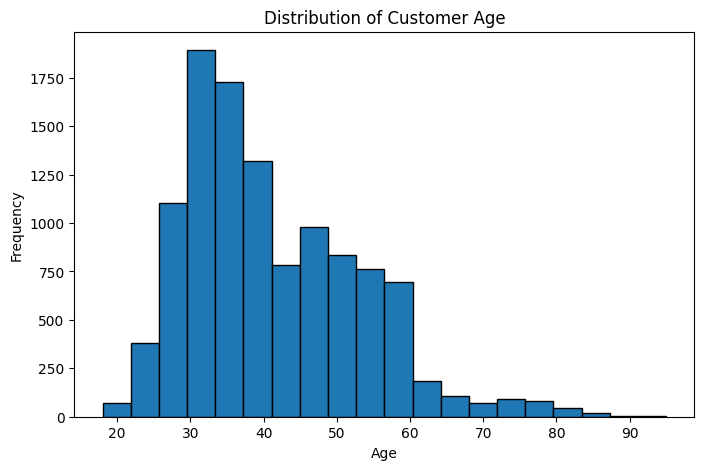

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=20, edgecolor='black')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

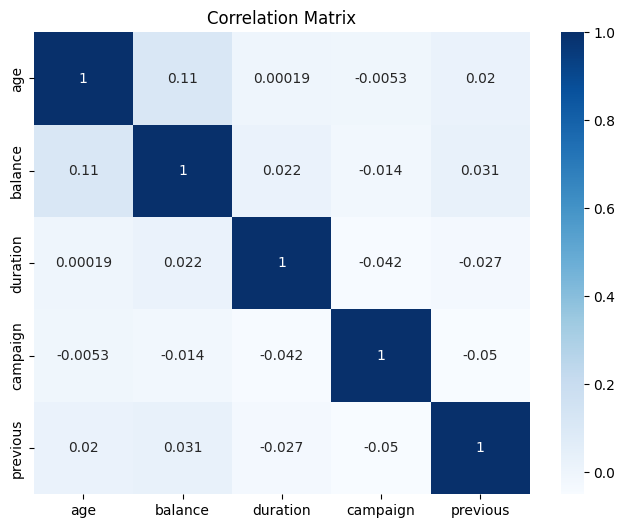

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    df[['age','balance','duration','campaign','previous']]
    .corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Matrix")
plt.show()

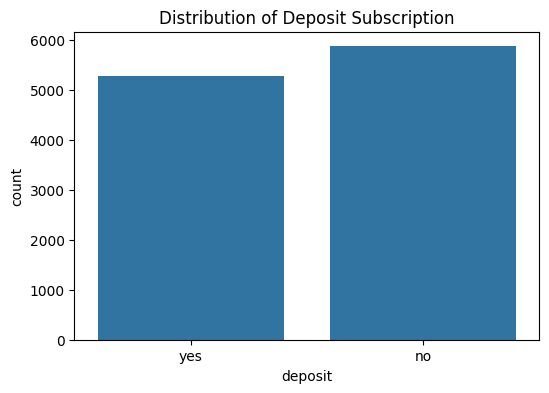

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='deposit'
)

plt.title("Distribution of Deposit Subscription")

plt.show()

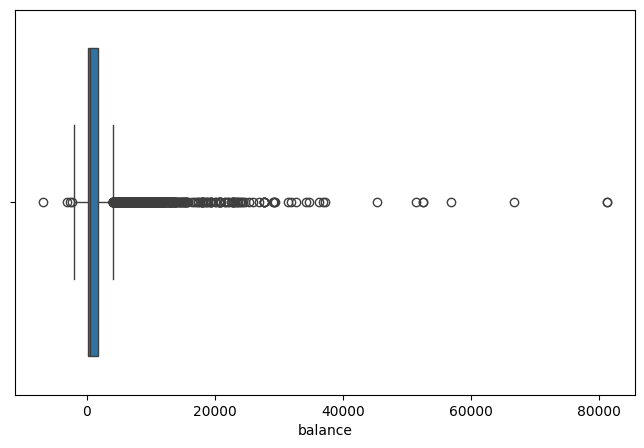

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df["balance"])
plt.show()

In [13]:
Q1 = df["balance"].quantile(0.25)
Q3 = df["balance"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df["balance"] < (Q1 - 1.5*IQR)) |
    (df["balance"] > (Q3 + 1.5*IQR))
]

print("Number of outliers:", len(outliers))

Number of outliers: 1055


In [14]:
# Display category counts for all categorical variables
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n===== {col.upper()} =====")
    print(df[col].value_counts())


===== JOB =====
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

===== MARITAL =====
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64

===== EDUCATION =====
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64

===== DEFAULT =====
default
no     10994
yes      168
Name: count, dtype: int64

===== HOUSING =====
housing
no     5881
yes    5281
Name: count, dtype: int64

===== LOAN =====
loan
no     9702
yes    1460
Name: count, dtype: int64

===== CONTACT =====
contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64

===== MONTH =====
month
may    2824
aug    1519
jul    1514
jun    1222
nov     943
apr     923
feb     776
o

In [15]:
# Check unknown category values in all categorical variables categorical_columns = df.select_dtypes(include='object').columns unknown_summary = pd.DataFrame({ 'Variable': categorical_columns, 'Unknown Count': [(df[col] == 'unknown').sum() for col in categorical_columns] }) unknown_summary

In [16]:
# Check unknown category values in all categorical variables categorical_columns = df.select_dtypes(include='object').columns unknown_summary = pd.DataFrame({ 'Variable': categorical_columns, 'Unknown Count': [(df[col] == 'unknown').sum() for col in categorical_columns] }) unknown_summary

In [17]:
import pandas as pd

categorical_columns = df.select_dtypes(include='object').columns

unknown_summary = pd.DataFrame({
    'Variable': categorical_columns,
    'Unknown Count': [(df[col] == 'unknown').sum() for col in categorical_columns]
})

unknown_summary

,Variable,Unknown Count
0,job,70
1,marital,0
2,education,497
3,default,0
4,housing,0
5,loan,0
6,contact,2346
7,month,0
8,poutcome,8326
9,deposit,0


In [18]:
import pandas as pd

# Select all categorical variables
categorical_columns = df.select_dtypes(include='object').columns

# Count 'unknown' values in each categorical variable
unknown_summary = pd.DataFrame({
    'Variable': categorical_columns,
    'Unknown Count': [(df[col] == 'unknown').sum() for col in categorical_columns],
    'Percentage (%)': [round((df[col] == 'unknown').sum() / len(df) * 100, 2)
                       for col in categorical_columns]
})

unknown_summary

,Variable,Unknown Count,Percentage (%)
0,job,70,0.63
1,marital,0,0.00
2,education,497,4.45
3,default,0,0.00
4,housing,0,0.00
5,loan,0,0.00
6,contact,2346,21.02
7,month,0,0.00
8,poutcome,8326,74.59
9,deposit,0,0.00


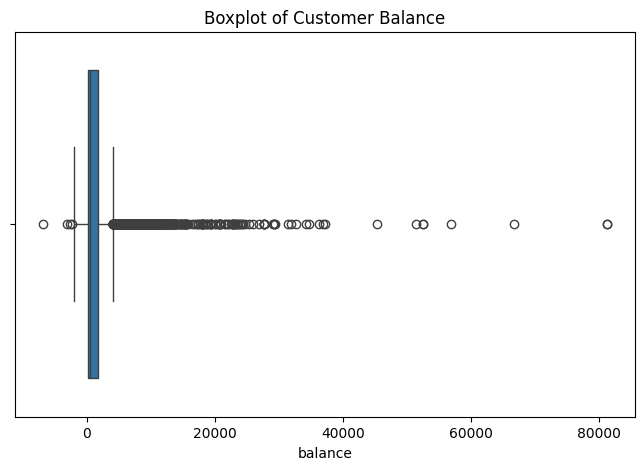

Number of potential outliers: 1055


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df['balance'])
plt.title('Boxplot of Customer Balance')
plt.show()
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df['balance'] < (Q1 - 1.5 * IQR)) |
    (df['balance'] > (Q3 + 1.5 * IQR))
]

print("Number of potential outliers:", len(outliers))

In [20]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
label_encoder = LabelEncoder()

# Select all categorical variables
categorical_columns = df.select_dtypes(include='object').columns

# Encode categorical variables
for col in categorical_columns:
   df[col] = label_encoder.fit_transform(df[col])

# Display transformed dataset
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


In [21]:
from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Select numerical variables
numerical_columns = [
    'age',
    'balance',
    'duration',
    'campaign',
    'pdays',
    'previous'
    ]

# Scale numerical variables
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# Display transformed dataset
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1.491505,0,1,1,0,0.252525,1,0,2,5,8,1.930226,-0.554168,-0.481184,-0.36326,3,1
1,1.239676,0,1,1,0,-0.459974,0,0,2,5,8,3.154612,-0.554168,-0.481184,-0.36326,3,1
2,-0.019470,9,1,1,0,-0.080160,1,0,2,5,8,2.929901,-0.554168,-0.481184,-0.36326,3,1
3,1.155733,7,1,1,0,0.293762,1,0,2,5,8,0.596366,-0.554168,-0.481184,-0.36326,3,1
4,1.071790,0,1,2,0,-0.416876,0,0,2,5,8,0.867171,-0.186785,-0.481184,-0.36326,3,1


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Features and target variable
X = df.drop('deposit', axis=1)
y = df['deposit']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Build baseline model
baseline_model = LogisticRegression(random_state=42)

# Train model
baseline_model.fit(X_train, y_train)

# Prediction
y_pred = baseline_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7895208240035826

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.82      0.80      1166
           1       0.79      0.76      0.77      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233


Confusion Matrix
[[955 211]
 [259 808]]


In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
print(le.fit(['yes', 'no']).classes_)

['no' 'yes']


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
...
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

In [25]:
print(baseline_model)

LogisticRegression(random_state=42)


In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict using the trained baseline model
y_pred = baseline_model.predict(X_test)

# Display evaluation results
print("Evaluation Results")
print("=" * 50)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

Evaluation Results
Accuracy: 0.7895

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.82      0.80      1166
           1       0.79      0.76      0.77      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233

Confusion Matrix
[[955 211]
 [259 808]]


In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
print(le.fit(['yes', 'no']).classes_)

['no' 'yes']


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Improved model using alternative algorithm and hyperparameter tuning
improved_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Train improved model
improved_model.fit(X_train, y_train)

# Predict
y_pred_improved = improved_model.predict(X_test)

# Model output
print(improved_model)

# Evaluation results
print("\nImproved Model: Random Forest Classifier")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_improved):.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_improved))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_improved))

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)

Improved Model: Random Forest Classifier
Accuracy: 0.8258

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1166
           1       0.80      0.85      0.82      1067

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233

Confusion Matrix
[[935 231]
 [158 909]]


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Improved model using alternative algorithm and hyperparameter tuning
improved_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Train the improved model
improved_model.fit(X_train, y_train)

# Generate predictions
y_pred_improved = improved_model.predict(X_test)

# Display model output
print(improved_model)

# Evaluate model performance
print("\nImproved Model: Random Forest Classifier")
print("=" * 50)

print(f"Accuracy: {accuracy_score(y_test, y_pred_improved):.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_improved))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_improved))

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)

Improved Model: Random Forest Classifier
Accuracy: 0.8258

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1166
           1       0.80      0.85      0.82      1067

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233

Confusion Matrix
[[935 231]
 [158 909]]


In [30]:
improved_model.fit(X_train, y_train)

y_pred_improved = improved_model.predict(X_test)

In [31]:
print(improved_model)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)


In [32]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_improved):.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_improved))

Accuracy: 0.8258

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1166
           1       0.80      0.85      0.82      1067

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



In [33]:
print(confusion_matrix(y_test, y_pred_improved))

[[935 231]
 [158 909]]


In [34]:
def validate_dataset(df):
    validation_results = {}

    # Check 1: Missing values
    validation_results["Missing Values"] = df.isnull().sum().sum()

    # Check 2: Duplicate rows
    validation_results["Duplicate Rows"] = df.duplicated().sum()

    # Check 3: Data type validation
    expected_numeric = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
    invalid_types = []

    for col in expected_numeric:
        if col in df.columns and not pd.api.types.is_numeric_dtype(df[col]):
            invalid_types.append(col)

    validation_results["Invalid Numeric Data Types"] = invalid_types

    # Check 4: Value range validation
    invalid_age = df[(df['age'] < 18) | (df['age'] > 100)].shape[0]
    validation_results["Invalid Age Range"] = invalid_age

    return validation_results


results = validate_dataset(df)

print("Automated Data Validation Results")
print("=" * 40)

for check, result in results.items():
    print(f"{check}: {result}")

Automated Data Validation Results
Missing Values: 0
Duplicate Rows: 0
Invalid Numeric Data Types: []
Invalid Age Range: 11162
